# Bird Species Observation Analysis
## Phase 2 : Exploratory Data Analysis (EDA)

**What this EDA covers ? :**

- Section A : Dataset Overview
- Section B : Temporal Analysis (when are birds observed)
- Section C : Spatial Analysis (where are birds observed)
- Section D : Species Analysis (which species, how many)
- Section E : Environmental Analysis (weather impact)
- Section F : Conservation Analysis (at-risk species)
- Section G : Key Findings Summary

---
## Step 1 : Import Libraries and Load Data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set a consistent visual style for all charts
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print('Libraries imported')

Libraries imported


In [24]:
# Load the cleaned CSV produced by 01_preprocessing.ipynb
df = pd.read_csv('bird_observations_clean.csv', low_memory=False)

# Re-parse the Date column since CSV stores dates as strings
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Re-map boolean columns back to True/False
# CSV stores them as the strings 'True' and 'False'
bool_cols = ['PIF_Watchlist_Status', 'Regional_Stewardship_Status',
             'Flyover_Observed', 'At_Risk', 'Initial_Three_Min_Cnt']
bool_map  = {'True': True, 'False': False, True: True, False: False}
for col in bool_cols:
    df[col] = df[col].map(bool_map)

print(f'Data loaded : {len(df):,} rows x {df.shape[1]} columns')

Data loaded : 14,264 rows x 43 columns


---
## Section A : Dataset Overview
Get a high-level understanding of what the data contains.

In [25]:
# Basic shape and column information
print('Shape            :', df.shape)
print('Date range       :', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Admin units      :', sorted(df['Admin_Unit_Code'].dropna().unique()))
print('Habitats         :', df['Habitat_Source'].unique().tolist())
print('Years covered    :', sorted(df['Year'].dropna().unique().astype(int)))

Shape            : (14264, 43)
Date range       : 2018-05-07 to 2018-07-19
Admin units      : ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
Habitats         : ['Forest', 'Grassland']
Years covered    : [np.int64(2018)]


In [26]:
# Key metrics summary
print('--- KEY METRICS ---')
print(f'Total observations       : {len(df):,}')
print(f'Unique species (common)  : {df["Common_Name"].nunique()}')
print(f'Unique species (science) : {df["Scientific_Name"].nunique()}')
print(f'PIF watchlist species    : {df[df["PIF_Watchlist_Status"]==True]["Common_Name"].nunique()}')
print(f'At-risk species          : {df[df["At_Risk"]==True]["Common_Name"].nunique()}')
print(f'Unique observers         : {df["Observer"].nunique()}')
print(f'Unique plots             : {df["Plot_Name"].nunique()}')

--- KEY METRICS ---
Total observations       : 14,264
Unique species (common)  : 126
Unique species (science) : 127
PIF watchlist species    : 8
At-risk species          : 25
Unique observers         : 3
Unique plots             : 609


In [27]:
# Null value check -- shows which columns still have missing data
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

print('Columns with null values:')
print(nulls.to_string())

Columns with null values:
Sub_Unit_Code        13598
Previously_Obs        7911
Disturbance_Level     6970
Site_Name             6353
Distance               624
Distance_Clean         624
Distance_Rank          624
AcceptedTSN             26
TaxonCode                2
ID_Method                1


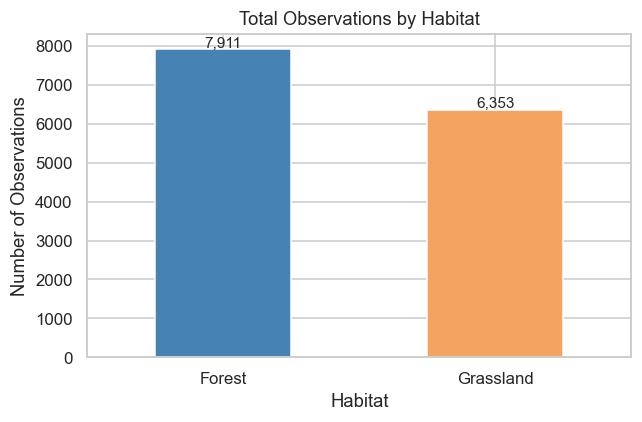

In [28]:
# Observation count split by habitat
habitat_counts = df['Habitat_Source'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
habitat_counts.plot(kind='bar', ax=ax, color=['steelblue', 'sandybrown'], edgecolor='white')

# Add count labels on top of each bar
for i, v in enumerate(habitat_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

ax.set_title('Total Observations by Habitat')
ax.set_xlabel('Habitat')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(habitat_counts.index, rotation=0)
plt.tight_layout()
plt.show()

---
## Section B : Temporal Analysis
Understanding WHEN birds are observed -- by month, season, and hour of day.

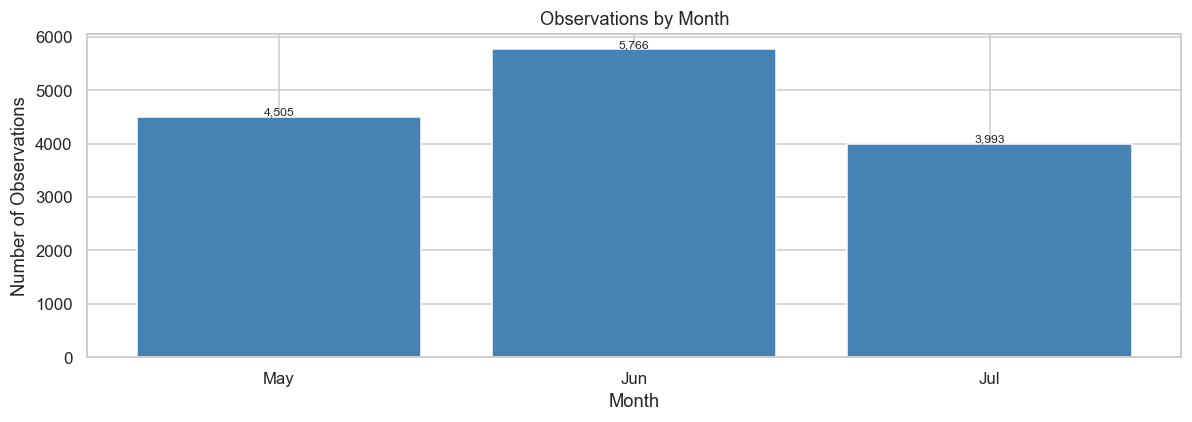

Peak month : Jun


In [29]:
# Monthly observation counts
# Group by month number to get correct chronological order
monthly = df.groupby(['Month', 'Month_Name']).size().reset_index(name='Observations')
monthly = monthly.sort_values('Month')   # sort by month number 1-12

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(monthly['Month_Name'], monthly['Observations'],
              color='steelblue', edgecolor='white')

# Add count label above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 30,
            f'{int(height):,}', ha='center', fontsize=8)

ax.set_title('Observations by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Observations')
plt.tight_layout()
plt.show()

print(f'Peak month : {monthly.loc[monthly["Observations"].idxmax(), "Month_Name"]}')

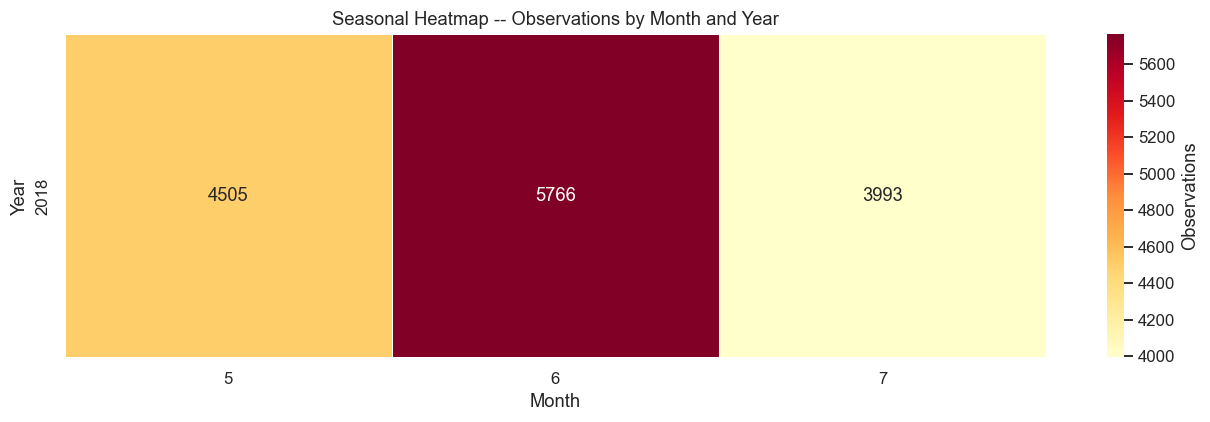

In [30]:
# Seasonal heatmap -- Month vs Year observation count
# pivot_table creates a grid with Year on rows and Month on columns
heat_data = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    heat_data,
    cmap='YlOrRd',          # yellow to red colour scale
    annot=True,              # show numbers inside each cell
    fmt='d',                 # format as integer
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Observations'}
)
ax.set_title('Seasonal Heatmap -- Observations by Month and Year')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

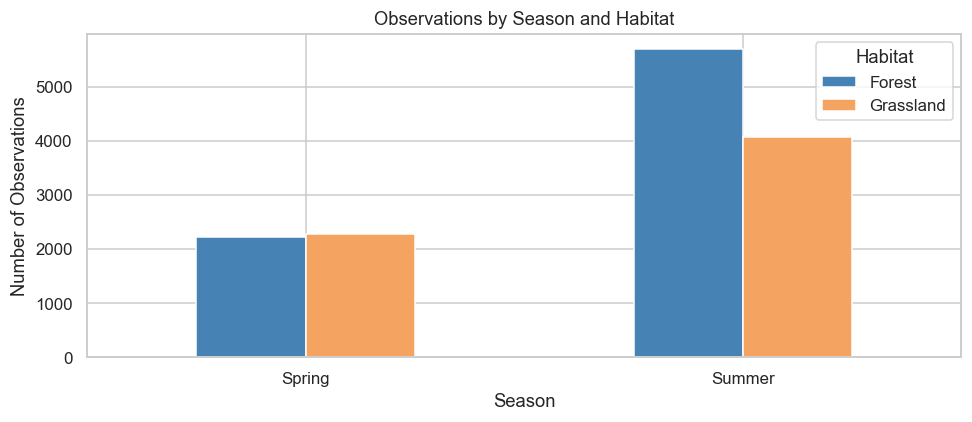

In [31]:
# Observations by season split by habitat
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

season_data = df.groupby(['Season', 'Habitat_Source']).size().unstack(fill_value=0)

# Reindex to show seasons in correct order
season_data = season_data.reindex([s for s in season_order if s in season_data.index])

fig, ax = plt.subplots(figsize=(9, 4))
season_data.plot(kind='bar', ax=ax, color=['steelblue', 'sandybrown'], edgecolor='white')

ax.set_title('Observations by Season and Habitat')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(season_data.index, rotation=0)
ax.legend(title='Habitat')
plt.tight_layout()
plt.show()

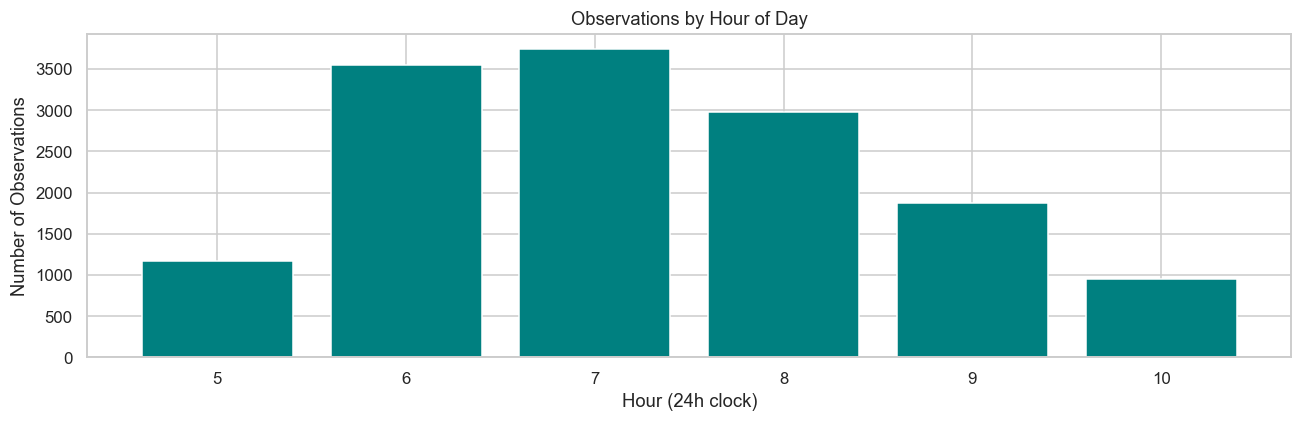

Peak observation hour : 7:00


In [32]:
# Peak activity hour -- birds are most active at dawn
# Start_Hour is 0-23 extracted from Start_Time in preprocessing
hour_data = (
    df['Start_Hour']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_data.index, hour_data.values, color='teal', edgecolor='white')

ax.set_title('Observations by Hour of Day')
ax.set_xlabel('Hour (24h clock)')
ax.set_ylabel('Number of Observations')
ax.set_xticks(range(int(hour_data.index.min()), int(hour_data.index.max()) + 1))
plt.tight_layout()
plt.show()

print(f'Peak observation hour : {hour_data.idxmax()}:00')

---
## Section C : Spatial Analysis
Understanding WHERE birds are observed -- by admin unit and plot.

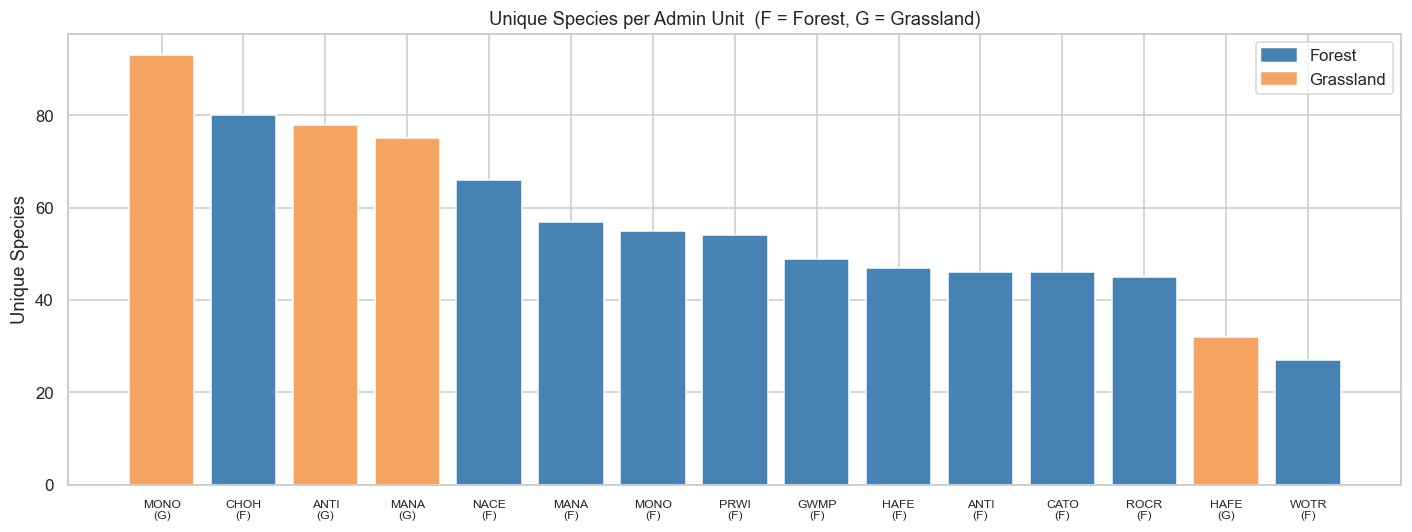

Admin_Unit_Code Habitat_Source  Unique_Species
           MONO      Grassland              93
           CHOH         Forest              80
           ANTI      Grassland              78
           MANA      Grassland              75
           NACE         Forest              66
           MANA         Forest              57
           MONO         Forest              55
           PRWI         Forest              54
           GWMP         Forest              49
           HAFE         Forest              47
           ANTI         Forest              46
           CATO         Forest              46
           ROCR         Forest              45
           HAFE      Grassland              32
           WOTR         Forest              27


In [33]:
# Species richness per admin unit (how many unique species at each park)
unit_richness = (
    df.groupby(['Admin_Unit_Code', 'Habitat_Source'])['Scientific_Name']
    .nunique()
    .reset_index(name='Unique_Species')
    .sort_values('Unique_Species', ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))

# Use different colours for Forest vs Grassland
colors = unit_richness['Habitat_Source'].map({'Forest': 'steelblue', 'Grassland': 'sandybrown'})
bars   = ax.bar(range(len(unit_richness)), unit_richness['Unique_Species'],
                color=colors, edgecolor='white')

# Label each bar with Admin Unit code and habitat initial
ax.set_xticks(range(len(unit_richness)))
ax.set_xticklabels(
    unit_richness['Admin_Unit_Code'] + '\n(' + unit_richness['Habitat_Source'].str[0] + ')',
    fontsize=8
)

ax.set_title('Unique Species per Admin Unit  (F = Forest, G = Grassland)')
ax.set_ylabel('Unique Species')

# Add a manual legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue',  label='Forest'),
    Patch(color='sandybrown', label='Grassland')
])
plt.tight_layout()
plt.show()

print(unit_richness.to_string(index=False))

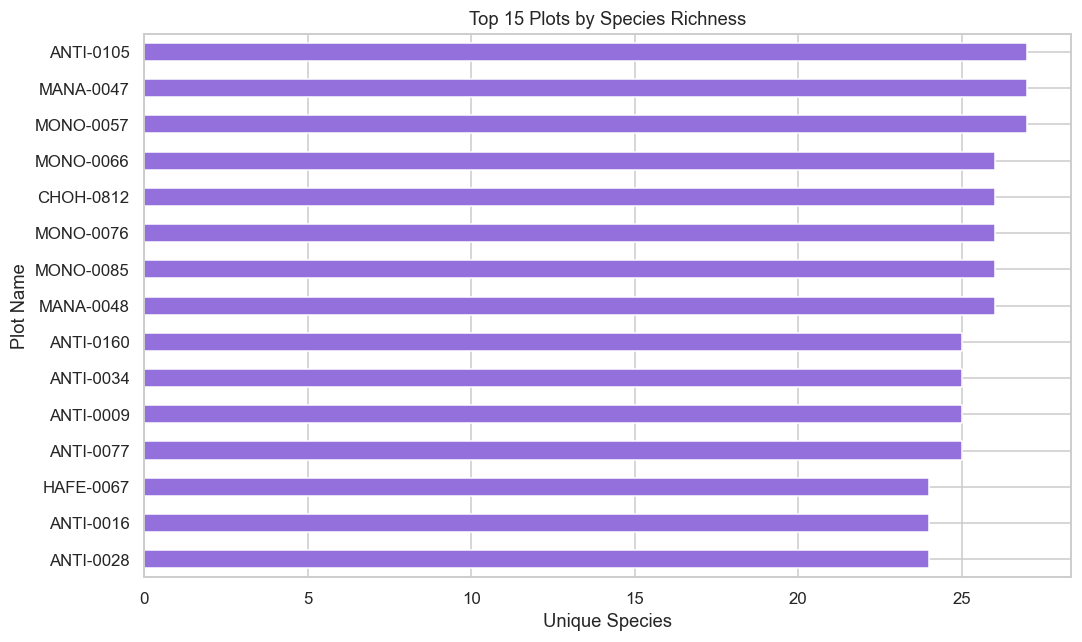

In [34]:
# Top 15 observation plots by species richness
# A plot is a specific survey location within a park
top_plots = (
    df.groupby('Plot_Name')['Scientific_Name']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_plots.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='white')

ax.set_title('Top 15 Plots by Species Richness')
ax.set_xlabel('Unique Species')
ax.set_ylabel('Plot Name')
ax.invert_yaxis()   # highest bar at top
plt.tight_layout()
plt.show()

---
## Section D : Species Analysis
Which species are observed, how often, and what detection method was used.

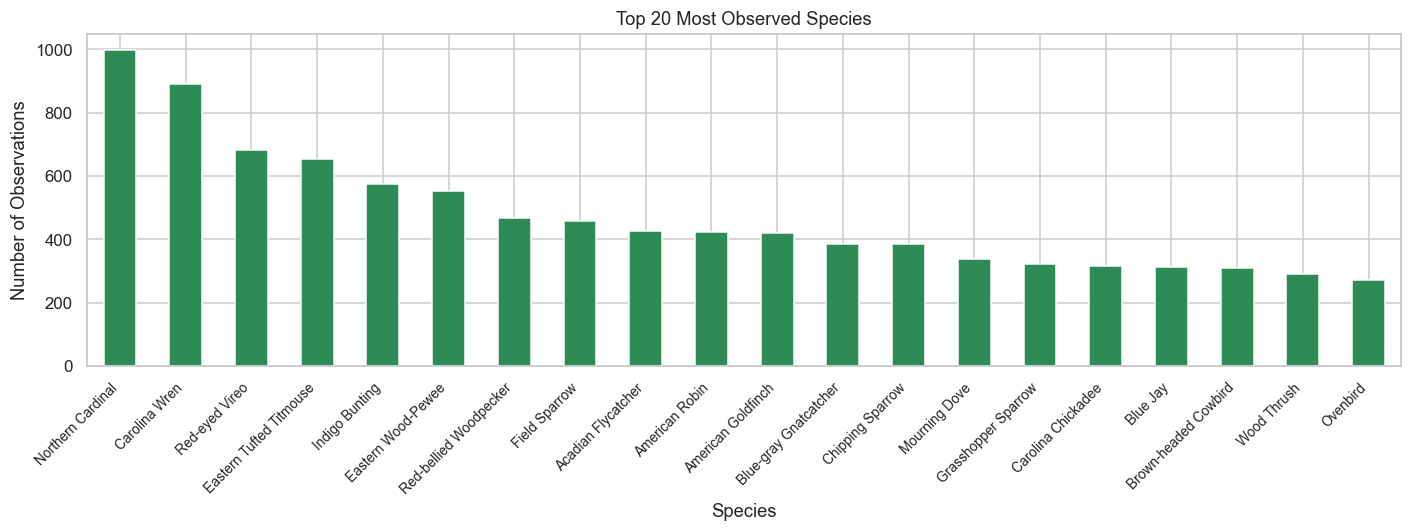

In [35]:
# Top 20 most observed species across both habitats
top_species = df['Common_Name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 5))
top_species.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')

ax.set_title('Top 20 Most Observed Species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(top_species.index, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

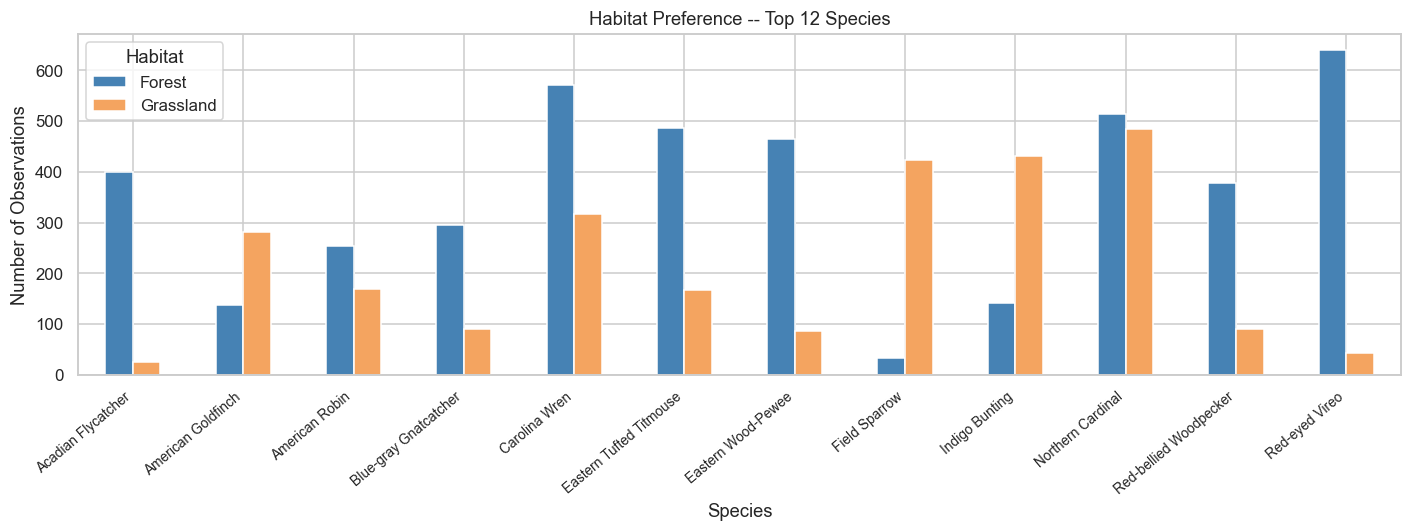

In [36]:
# Species habitat preference -- does a species prefer Forest or Grassland?
# Show top 12 species split by habitat
top12 = df['Common_Name'].value_counts().head(12).index

habitat_pref = (
    df[df['Common_Name'].isin(top12)]
    .groupby(['Common_Name', 'Habitat_Source'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
habitat_pref.plot(
    kind='bar', ax=ax,
    color=['steelblue', 'sandybrown'],
    edgecolor='white'
)
ax.set_title('Habitat Preference -- Top 12 Species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(habitat_pref.index, rotation=40, ha='right', fontsize=9)
ax.legend(title='Habitat')
plt.tight_layout()
plt.show()

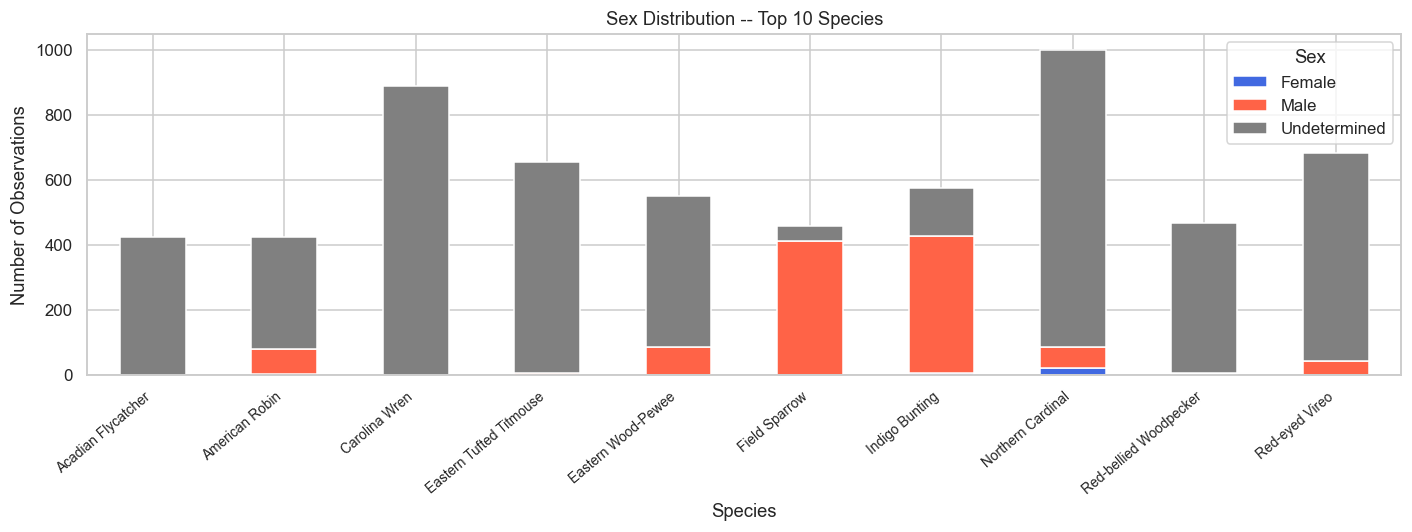

In [37]:
# Sex ratio for the top 10 most observed species
# Only include rows where sex is known
sex_data = df[df['Sex'].isin(['Male', 'Female', 'Undetermined'])]
top10    = sex_data['Common_Name'].value_counts().head(10).index

sex_ratio = (
    sex_data[sex_data['Common_Name'].isin(top10)]
    .groupby(['Common_Name', 'Sex'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
sex_ratio.plot(
    kind='bar', stacked=True, ax=ax,
    color=['royalblue', 'tomato', 'grey'],
    edgecolor='white'
)
ax.set_title('Sex Distribution -- Top 10 Species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(sex_ratio.index, rotation=40, ha='right', fontsize=9)
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

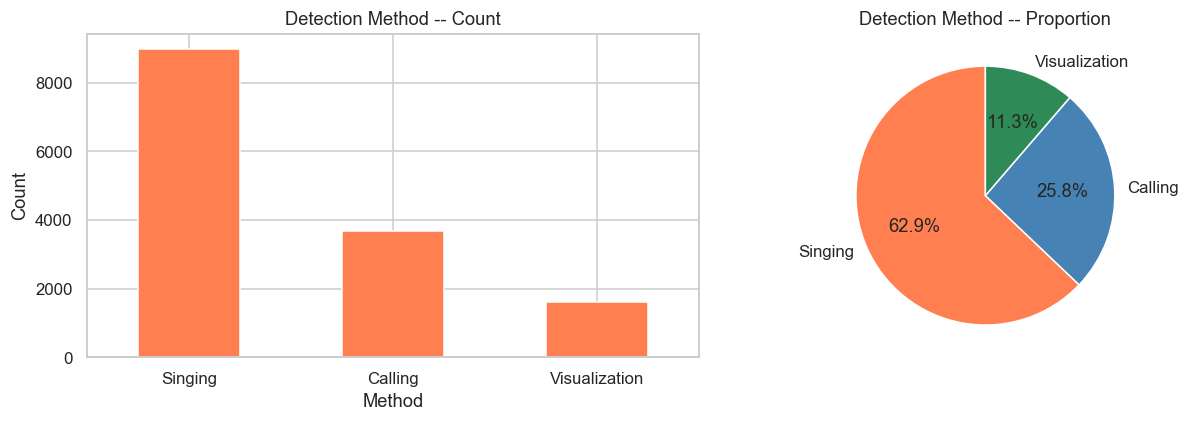

In [38]:
# Detection method -- how were birds identified (singing, calling, seen)
id_counts = df['ID_Method'].value_counts(dropna=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart -- shows exact counts
id_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Detection Method -- Count')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(id_counts.index, rotation=0)

# Pie chart -- shows proportion
axes[1].pie(
    id_counts.values,
    labels=id_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['coral', 'steelblue', 'seagreen'],
    wedgeprops=dict(edgecolor='white')
)
axes[1].set_title('Detection Method -- Proportion')

plt.tight_layout()
plt.show()

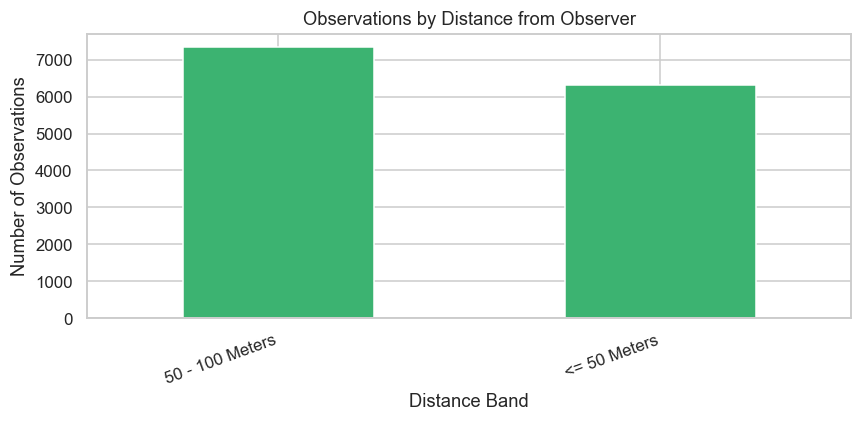

In [39]:
# Distance at which birds were observed
# This tells us how close observers get to each species
distance_counts = df['Distance_Clean'].value_counts(dropna=True)

fig, ax = plt.subplots(figsize=(8, 4))
distance_counts.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')

ax.set_title('Observations by Distance from Observer')
ax.set_xlabel('Distance Band')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(distance_counts.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## Section E : Environmental Analysis
How do weather conditions affect bird observations?

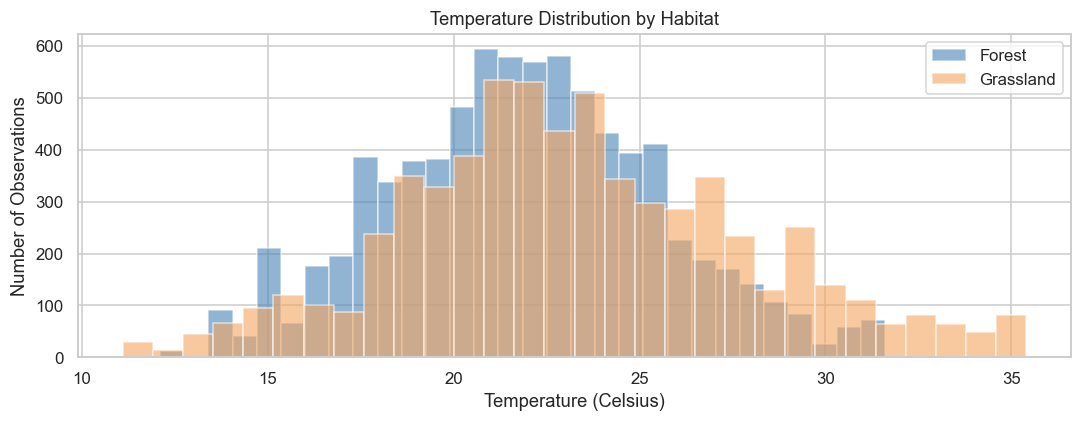

Temperature statistics per habitat:
                 count  mean  std   min   25%   50%   75%   max
Habitat_Source                                                 
Forest          7911.0  21.9  3.6  12.1  19.4  21.9  24.4  31.6
Grassland       6353.0  23.3  4.6  11.1  20.2  22.8  26.4  35.4


In [40]:
# Temperature distribution per habitat
# Shows Forest is cooler, Grassland is warmer -- validates our separate IQR approach
fig, ax = plt.subplots(figsize=(10, 4))

for habitat, color in [('Forest', 'steelblue'), ('Grassland', 'sandybrown')]:
    subset = df[df['Habitat_Source'] == habitat]['Temperature'].dropna()
    ax.hist(subset, bins=30, alpha=0.6, color=color, edgecolor='white', label=habitat)

ax.set_title('Temperature Distribution by Habitat')
ax.set_xlabel('Temperature (Celsius)')
ax.set_ylabel('Number of Observations')
ax.legend()
plt.tight_layout()
plt.show()

# Print summary statistics for each habitat
print('Temperature statistics per habitat:')
print(df.groupby('Habitat_Source')['Temperature']
       .describe().round(1).to_string())

Pearson correlation (Temperature vs Humidity) : r = -0.337
P-value : 0.0000
Interpretation : significant correlation


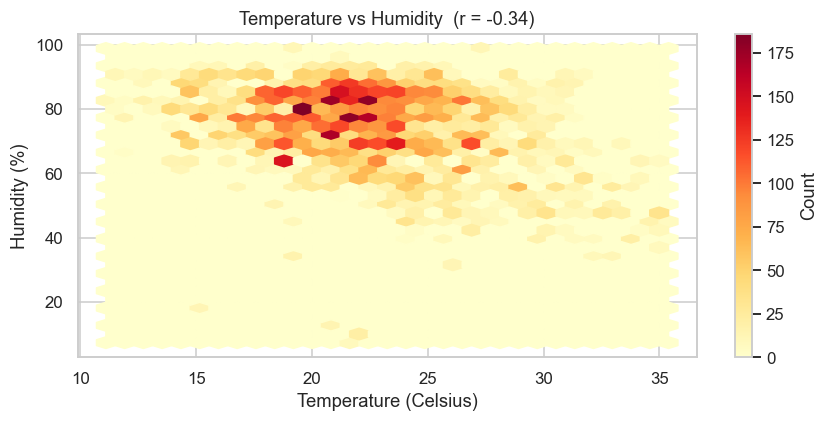

In [41]:
# Correlation between Temperature and Humidity
# Pearson r measures linear relationship: +1 = positive, -1 = negative, 0 = none
valid = df[['Temperature', 'Humidity']].dropna()
r, p_value = stats.pearsonr(valid['Temperature'], valid['Humidity'])

print(f'Pearson correlation (Temperature vs Humidity) : r = {r:.3f}')
print(f'P-value : {p_value:.4f}')
print(f'Interpretation : {"significant" if p_value < 0.05 else "not significant"} correlation')

fig, ax = plt.subplots(figsize=(8, 4))

# Hexbin is better than scatter for large datasets -- groups nearby points into cells
hb = ax.hexbin(valid['Temperature'], valid['Humidity'], gridsize=30, cmap='YlOrRd')
plt.colorbar(hb, ax=ax, label='Count')

ax.set_title(f'Temperature vs Humidity  (r = {r:.2f})')
ax.set_xlabel('Temperature (Celsius)')
ax.set_ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

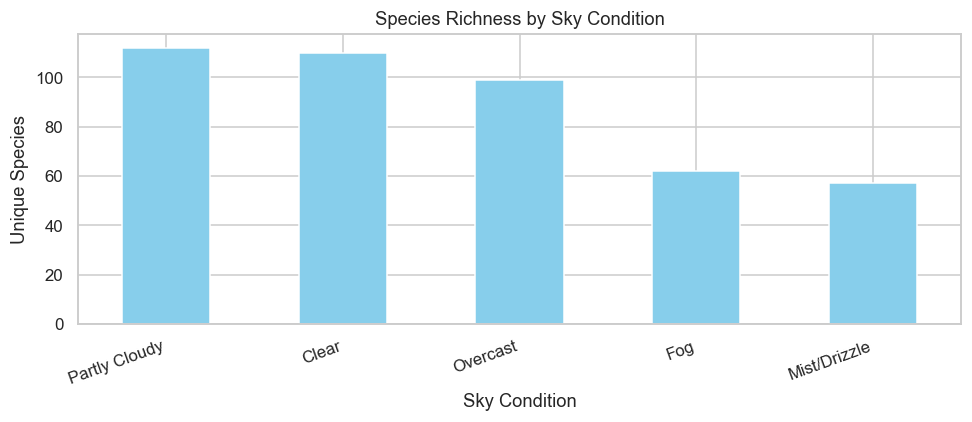

In [42]:
# Sky condition vs number of species observed
# Clear skies should have more observations than foggy or rainy conditions
sky_richness = (
    df.groupby('Sky_Clean')['Scientific_Name']
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
sky_richness.plot(kind='bar', ax=ax, color='skyblue', edgecolor='white')

ax.set_title('Species Richness by Sky Condition')
ax.set_xlabel('Sky Condition')
ax.set_ylabel('Unique Species')
ax.set_xticklabels(sky_richness.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()

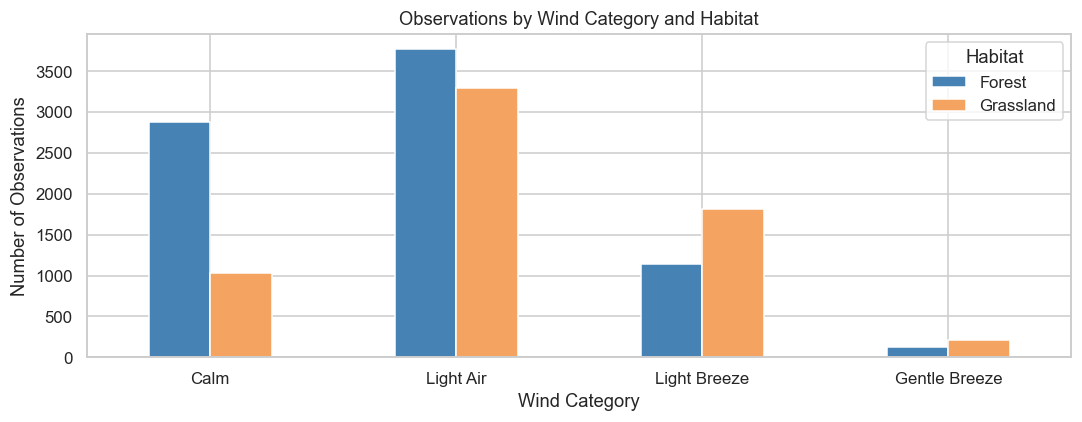

In [43]:
# Wind category vs observations
# Strong wind makes it harder to hear birds -- expect fewer observations
wind_obs = (
    df.groupby(['Wind_Category', 'Habitat_Source'])
    .size()
    .unstack(fill_value=0)
)

# Reorder wind categories from calm to strong
wind_order = ['Calm', 'Light Air', 'Light Breeze', 'Gentle Breeze', 'Strong']
wind_obs = wind_obs.reindex([w for w in wind_order if w in wind_obs.index])

fig, ax = plt.subplots(figsize=(10, 4))
wind_obs.plot(kind='bar', ax=ax, color=['steelblue', 'sandybrown'], edgecolor='white')

ax.set_title('Observations by Wind Category and Habitat')
ax.set_xlabel('Wind Category')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(wind_obs.index, rotation=0)
ax.legend(title='Habitat')
plt.tight_layout()
plt.show()

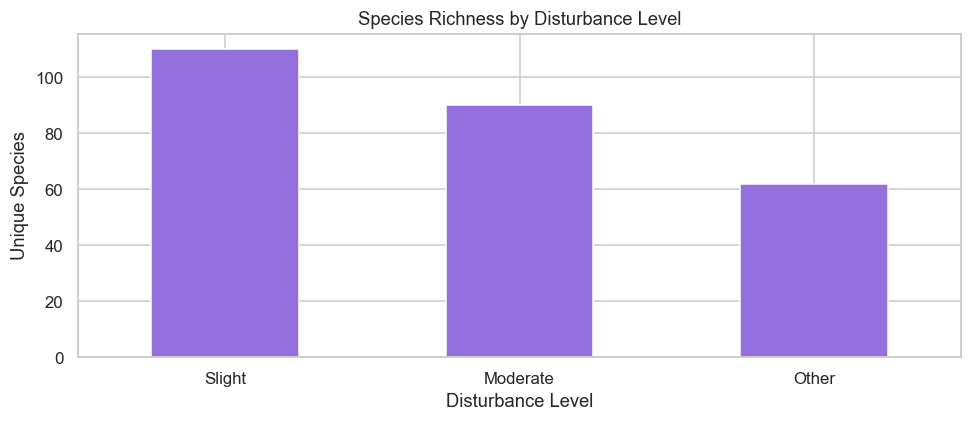

In [44]:
# Disturbance level vs species richness
# High disturbance areas should have fewer species
disturbance_order = ['None', 'Slight', 'Moderate', 'High', 'Other']

dist_richness = df.groupby('Disturbance_Level')['Scientific_Name'].nunique()
dist_richness = dist_richness.reindex(
    [d for d in disturbance_order if d in dist_richness.index]
)

fig, ax = plt.subplots(figsize=(9, 4))
dist_richness.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')

ax.set_title('Species Richness by Disturbance Level')
ax.set_xlabel('Disturbance Level')
ax.set_ylabel('Unique Species')
ax.set_xticklabels(dist_richness.index, rotation=0)
plt.tight_layout()
plt.show()

---
## Section F : Conservation Analysis
Focus on at-risk species -- species on the PIF watchlist or regional priority list.

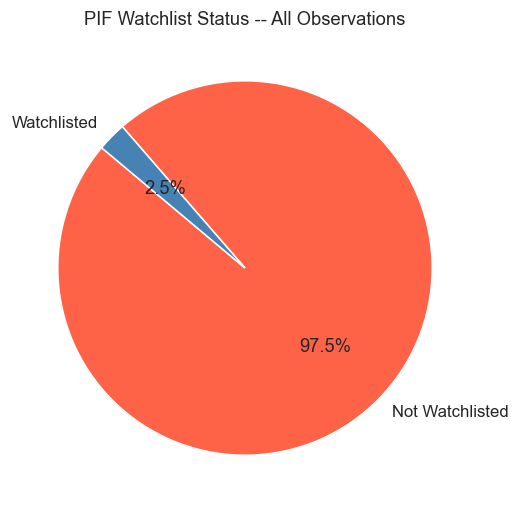

In [45]:
# PIF watchlist vs non-watchlist split
watchlist_counts = (
    df['PIF_Watchlist_Status']
    .map({True: 'Watchlisted', False: 'Not Watchlisted'})
    .value_counts()
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    watchlist_counts.values,
    labels=watchlist_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['tomato', 'steelblue'],
    wedgeprops=dict(edgecolor='white')
)
ax.set_title('PIF Watchlist Status -- All Observations')
plt.tight_layout()
plt.show()

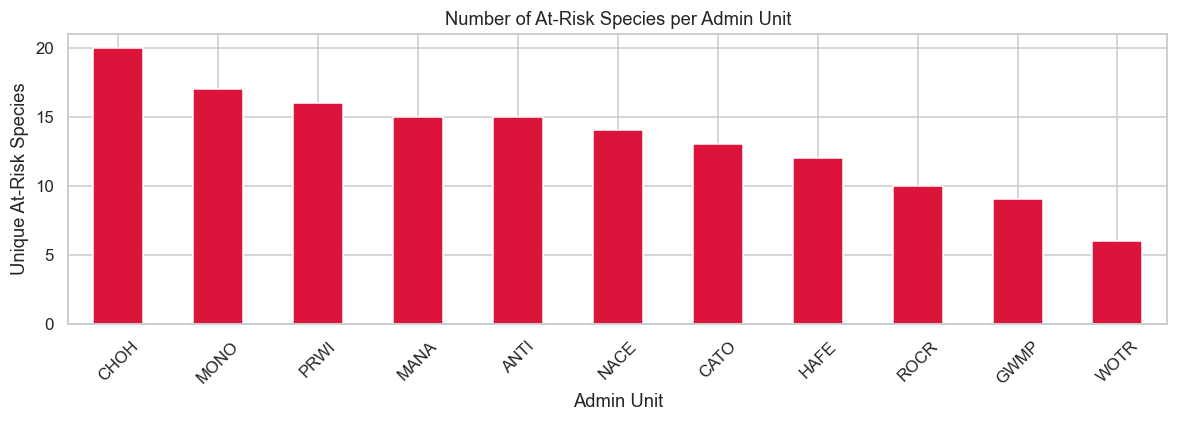

In [46]:
# At-risk species count per admin unit
# Which parks have the most species that need conservation attention?
atrisk_by_unit = (
    df[df['At_Risk'] == True]
    .groupby('Admin_Unit_Code')['Common_Name']
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 4))
atrisk_by_unit.plot(kind='bar', ax=ax, color='crimson', edgecolor='white')

ax.set_title('Number of At-Risk Species per Admin Unit')
ax.set_xlabel('Admin Unit')
ax.set_ylabel('Unique At-Risk Species')
ax.set_xticklabels(atrisk_by_unit.index, rotation=45)
plt.tight_layout()
plt.show()

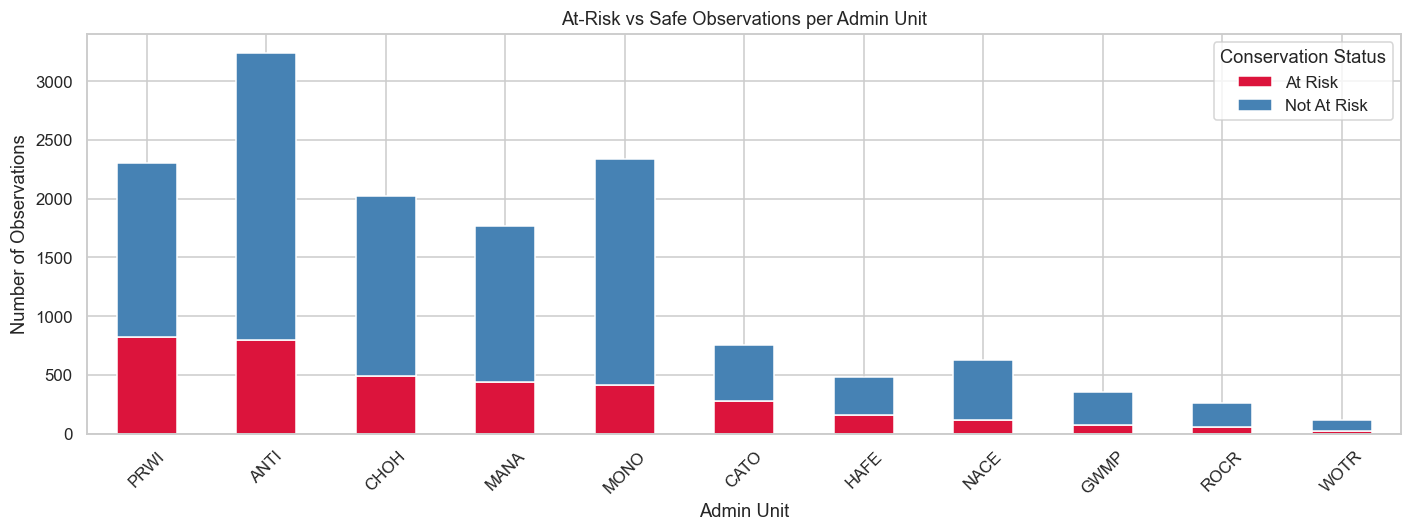

In [47]:
# At-risk vs safe observations stacked -- per admin unit
# Shows conservation burden relative to total survey effort
conservation = df.groupby('Admin_Unit_Code').apply(
    lambda x: pd.Series({
        'At Risk'  : (x['At_Risk'] == True).sum(),
        'Not At Risk': (x['At_Risk'] == False).sum()
    })
).sort_values('At Risk', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
conservation.plot(
    kind='bar', stacked=True, ax=ax,
    color=['crimson', 'steelblue'],
    edgecolor='white'
)
ax.set_title('At-Risk vs Safe Observations per Admin Unit')
ax.set_xlabel('Admin Unit')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(conservation.index, rotation=45)
ax.legend(title='Conservation Status')
plt.tight_layout()
plt.show()

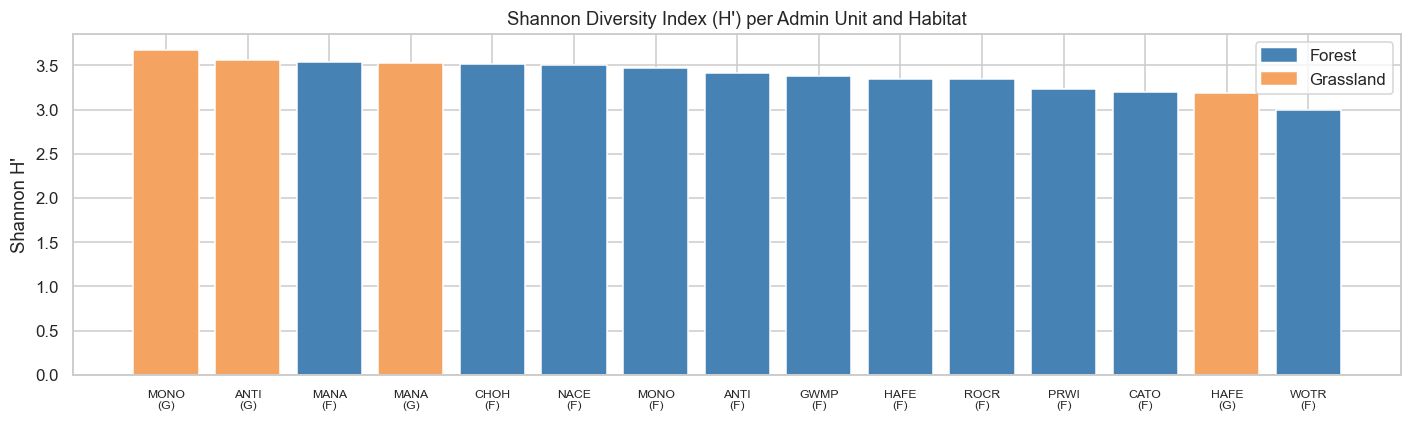

Admin_Unit_Code Habitat_Source  Shannon_H
           MONO      Grassland   3.672489
           ANTI      Grassland   3.561365
           MANA         Forest   3.533490
           MANA      Grassland   3.526854
           CHOH         Forest   3.515806
           NACE         Forest   3.502327
           MONO         Forest   3.474085
           ANTI         Forest   3.412610
           GWMP         Forest   3.374427
           HAFE         Forest   3.349479
           ROCR         Forest   3.343787
           PRWI         Forest   3.231408
           CATO         Forest   3.202118
           HAFE      Grassland   3.184874
           WOTR         Forest   2.994639


In [48]:
# Shannon Diversity Index per admin unit and habitat
# H' = 0 means only one species, higher H' means more diverse
# Formula: H' = -sum(p * log(p))  where p = proportion of each species

def shannon_diversity(species_series):
    counts = species_series.value_counts()
    proportions = counts / counts.sum()
    # Small value 1e-12 added to avoid log(0) error
    return float(-np.sum(proportions * np.log(proportions + 1e-12)))

shannon_df = (
    df.groupby(['Admin_Unit_Code', 'Habitat_Source'])['Scientific_Name']
    .apply(shannon_diversity)
    .reset_index(name="Shannon_H")
    .sort_values("Shannon_H", ascending=False)
)

colors = shannon_df['Habitat_Source'].map({'Forest': 'steelblue', 'Grassland': 'sandybrown'})

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(shannon_df)), shannon_df['Shannon_H'], color=colors, edgecolor='white')

ax.set_xticks(range(len(shannon_df)))
ax.set_xticklabels(
    shannon_df['Admin_Unit_Code'] + '\n(' + shannon_df['Habitat_Source'].str[0] + ')',
    fontsize=8
)
ax.set_title("Shannon Diversity Index (H') per Admin Unit and Habitat")
ax.set_ylabel("Shannon H'")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue',  label='Forest'),
    Patch(color='sandybrown', label='Grassland')
])
plt.tight_layout()
plt.show()

print(shannon_df.to_string(index=False))

---
## Section G : Key Findings Summary
A consolidated summary of the most important insights from the analysis.

In [49]:
# Collect all key findings in one place

# Most diverse unit
unit_div = (
    df.groupby(['Admin_Unit_Code', 'Habitat_Source'])['Scientific_Name']
    .nunique()
    .reset_index(name='Unique_Species')
)
top_unit = unit_div.sort_values('Unique_Species', ascending=False).iloc[0]

# Peak hour
peak_hour = (
    df['Start_Hour'].dropna().astype(int)
    .value_counts().idxmax()
)

# Peak month
peak_month = df['Month_Name'].value_counts().idxmax()

# Most observed species
top_species = df['Common_Name'].value_counts().idxmax()

# Most at-risk unit
top_atrisk_unit = (
    df[df['At_Risk'] == True]
    .groupby('Admin_Unit_Code')['Common_Name']
    .nunique().idxmax()
)

# Best sky condition
best_sky = (
    df.groupby('Sky_Clean')['Scientific_Name']
    .nunique().idxmax()
)

print('=' * 55)
print('KEY FINDINGS')
print('=' * 55)
print(f'Total observations    : {len(df):,}')
print(f'Total unique species  : {df["Common_Name"].nunique()}')
print()
print(f'Most diverse unit     : {top_unit["Admin_Unit_Code"]} ({top_unit["Habitat_Source"]}) -- {top_unit["Unique_Species"]} species')
print(f'Peak survey month     : {peak_month}')
print(f'Peak activity hour    : {peak_hour}:00')
print(f'Most observed species : {top_species}')
print()
print(f'At-risk species total : {df[df["At_Risk"]==True]["Common_Name"].nunique()}')
print(f'Most at-risk unit     : {top_atrisk_unit}')
print(f'PIF watchlist species : {df[df["PIF_Watchlist_Status"]==True]["Common_Name"].nunique()}')
print()
print(f'Best sky for obs      : {best_sky}')
print(f'Most common wind      : {df["Wind_Category"].value_counts().idxmax()}')
print(f'Pearson r (Temp/Hum)  : {round(stats.pearsonr(df[["Temperature","Humidity"]].dropna()["Temperature"], df[["Temperature","Humidity"]].dropna()["Humidity"])[0], 3)}')

KEY FINDINGS
Total observations    : 14,264
Total unique species  : 126

Most diverse unit     : MONO (Grassland) -- 93 species
Peak survey month     : Jun
Peak activity hour    : 7:00
Most observed species : Northern Cardinal

At-risk species total : 25
Most at-risk unit     : CHOH
PIF watchlist species : 8

Best sky for obs      : Partly Cloudy
Most common wind      : Light Air
Pearson r (Temp/Hum)  : -0.337
